In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

ds = xr.open_dataset('../../data/raw/tmax/tmax_1982_06.nc', engine='netcdf4')


In [19]:
print(ds.time)

<xarray.DataArray 'time' (time: 30)> Size: 240B
array(['1982-06-01T00:00:00.000000000', '1982-06-02T00:00:00.000000000',
       '1982-06-03T00:00:00.000000000', '1982-06-04T00:00:00.000000000',
       '1982-06-05T00:00:00.000000000', '1982-06-06T00:00:00.000000000',
       '1982-06-07T00:00:00.000000000', '1982-06-08T00:00:00.000000000',
       '1982-06-09T00:00:00.000000000', '1982-06-10T00:00:00.000000000',
       '1982-06-11T00:00:00.000000000', '1982-06-12T00:00:00.000000000',
       '1982-06-13T00:00:00.000000000', '1982-06-14T00:00:00.000000000',
       '1982-06-15T00:00:00.000000000', '1982-06-16T00:00:00.000000000',
       '1982-06-17T00:00:00.000000000', '1982-06-18T00:00:00.000000000',
       '1982-06-19T00:00:00.000000000', '1982-06-20T00:00:00.000000000',
       '1982-06-21T00:00:00.000000000', '1982-06-22T00:00:00.000000000',
       '1982-06-23T00:00:00.000000000', '1982-06-24T00:00:00.000000000',
       '1982-06-25T00:00:00.000000000', '1982-06-26T00:00:00.000000000',
   

In [20]:
temp = ds['t2m'].sel(time='1982-06-01T00:00:00.000000000')

# <已移除：此处曾硬编码服务器凭据，请勿把密码写进 notebook>
cat > /opt/tcc/.cdsapirc <<'EOF'
url: https://cds.climate.copernicus.eu/api
key: 4dbd8645-c272-4f5f-8e86-09f77e64f327
EOF
chmod 600 /opt/tcc/.cdsapirc

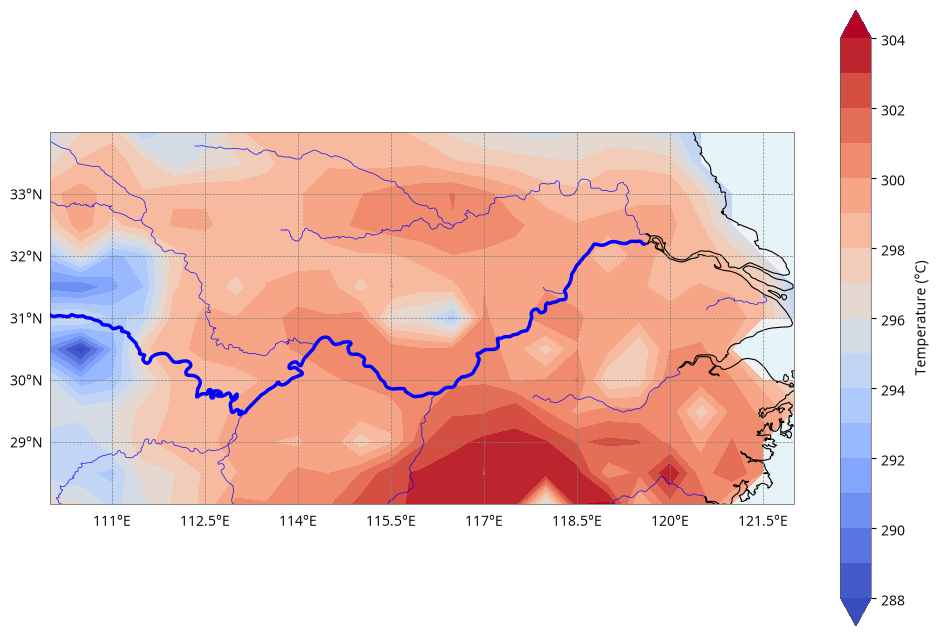

In [22]:
from cartopy.io import shapereader
from cartopy.feature import ShapelyFeature
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
river_path = shapereader.natural_earth(
    resolution='10m',
    category='physical',
    name='rivers_lake_centerlines'
)
reader = shapereader.Reader(river_path)

yangtze_geoms = []
for record in reader.records():
    name = record.attributes.get('name', '')
    if 'Yangtze' in name or 'Chang Jiang' in name or 'Changjiang' in name:
        yangtze_geoms.append(record.geometry)

yangtze_feature = ShapelyFeature(
    yangtze_geoms,
    ccrs.PlateCarree(),
    facecolor='none',
    edgecolor='blue',
    linewidth=2.5,
    linestyle='-',
    alpha=1.0
)


fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())


ax.set_extent([110, 122, 28, 34], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.3)
ax.add_feature(cfeature.RIVERS, edgecolor='blue', linewidth=0.6, alpha=0.8, zorder=2)
ax.add_feature(yangtze_feature, zorder=5)

cf = ax.contourf(
    temp.longitude, temp.latitude, temp,
    levels=20,
    cmap="coolwarm",
    transform=ccrs.PlateCarree(),
    extend="both"
)

cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.05, shrink=0.8)
cbar.set_label("Temperature (°C)")

gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False
plt.tight_layout()
plt.savefig("temperature_map.png", dpi=300)
plt.show()